In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import random
sys.path.append(os.path.abspath("../"))

# KMP_DUPLICATE_LIB_OK=TRUE
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
from omegaconf import OmegaConf
from src.vae_model import VAESmall, VAEMedium, VAELarge, BetaVAE, VAEPlus
import numpy as np
from tqdm import tqdm

def load_model_and_cfg(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    cfg = OmegaConf.create(checkpoint["config"])
    cfg.data.train_path = "D:/BBBC021/BBBC021_dataset_cleaned_maxnorm_68.h5"
    cfg.data.metadata_path = "../data/raw/metadata_dataset.h5"

    # Initialize model based on configuration
    name = cfg.model.name
    if name in ("VAESmall"):
        model = VAESmall(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAEMedium"):
        model = VAEMedium(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAELarge"):
        model = VAELarge(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("Beta_VAE"):
        model = BetaVAE(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta)
    elif name in ("VAE+"):
        model = VAEPlus(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta, cfg.model.adv_schedule_slope)

    # Load model state dict
    model.cfg = cfg
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [3]:
model_plus = load_model_and_cfg("../experiments/models/VAEPlus/large_32_32_32_64_2.pth")
from src.data_loading_well import load_data_by_well
cfg = model_plus.cfg
test_loader = load_data_by_well(cfg, split="test")

Total wells Train: 770, Val: 96, Test: 96
Total images in test: 46458 (9.66% of total)


In [4]:
idx = 8428
image = test_loader.dataset[idx][0].unsqueeze(0)

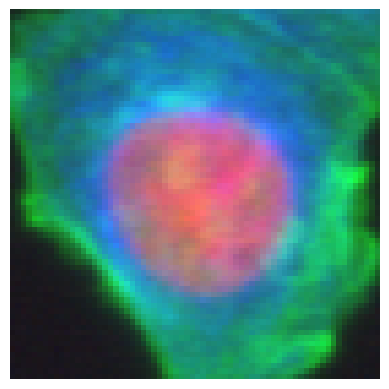

In [23]:
# plot the image
plt.imshow(image.squeeze(0).permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

In [53]:
def plot_feature_map_rgb_composites(fmap, max_plots=10):
    """
    Plot feature maps as RGB composites by grouping 3 channels together.
    """
    fmap = fmap.squeeze(0)  # (C, H, W)
    C, H, W = fmap.shape
    n = min(C // 3, max_plots)

    fig, axs = plt.subplots(1, n, figsize=(2.5 * n, 2.5))

    for i in range(n):
        # Stack 3 channels into RGB
        rgb = fmap[i*3:i*3+3]  # (3, H, W)
        rgb = rgb.permute(1, 2, 0).cpu().detach().numpy()  # (H, W, 3)

        # Normalize each RGB composite to [0, 1]
        rgb -= rgb.min()
        rgb /= (rgb.max() + 1e-5)

        ax = axs[i] if n > 1 else axs
        ax.imshow(rgb)
        ax.set_title(f"RGB map {i+1}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

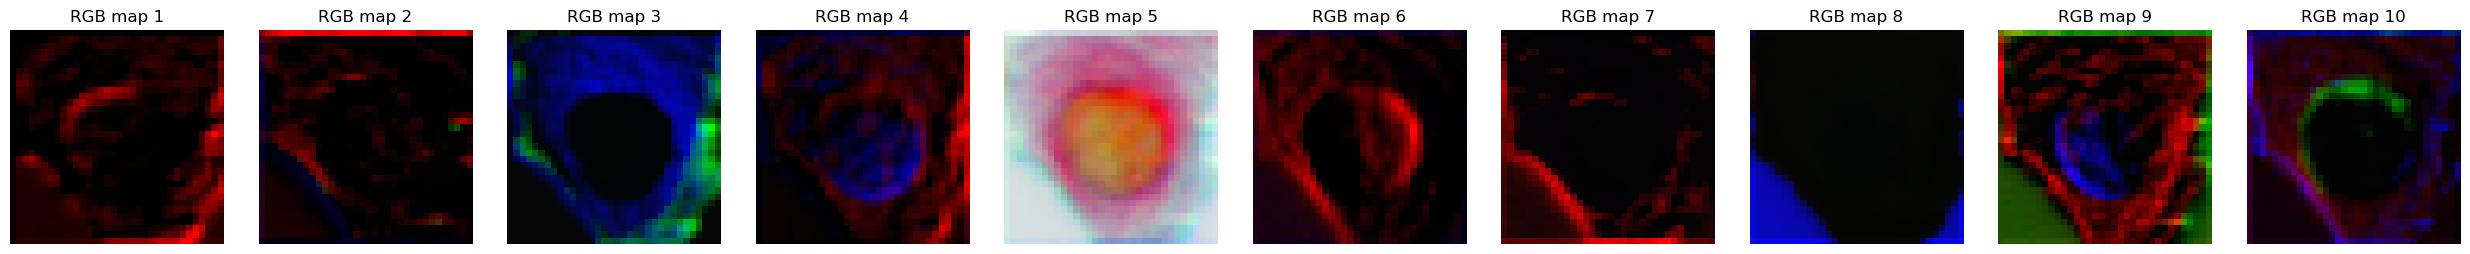

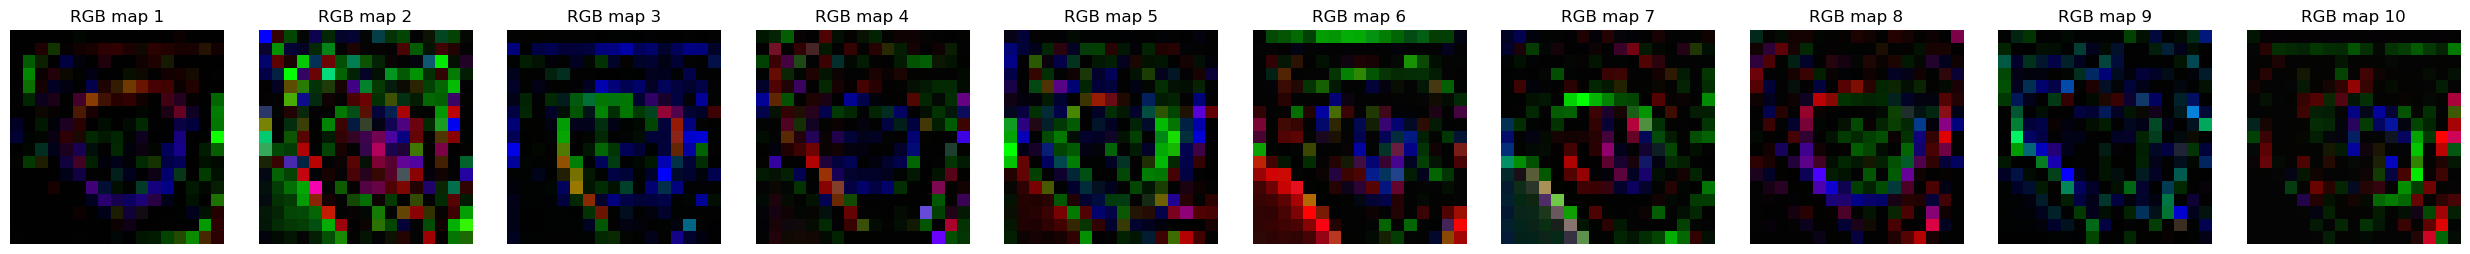

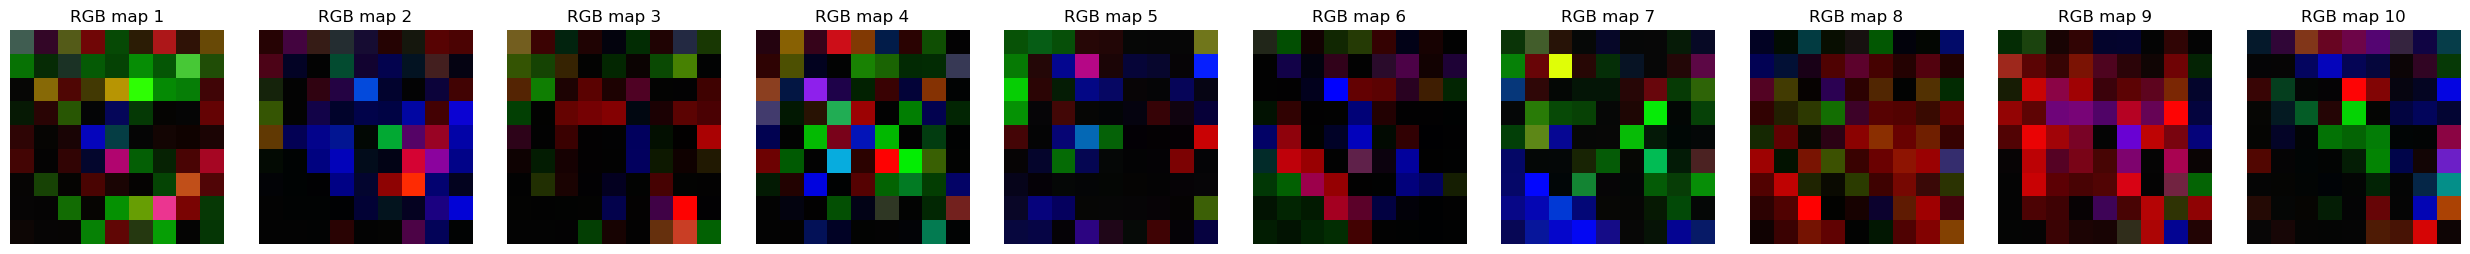

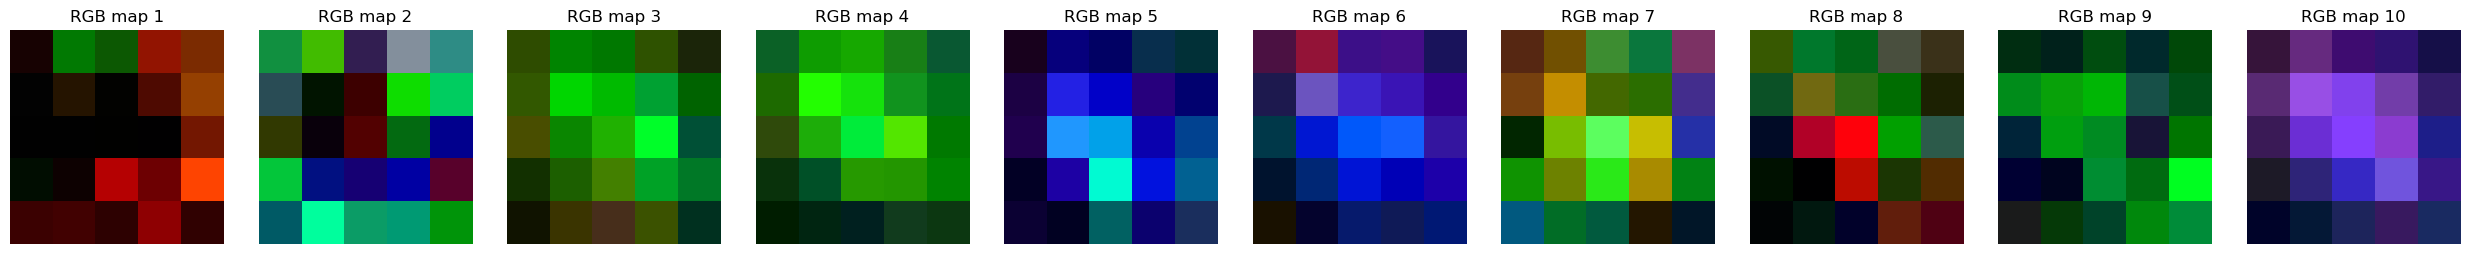

In [54]:
logits, feature_maps = model_plus.discriminator(image)

# Example: visualize composite RGBs for each block
for i, fmap in enumerate(feature_maps):
    plot_feature_map_rgb_composites(fmap)